<a href="https://colab.research.google.com/github/Tedodor423/bms-collab-notebooks/blob/main/1.3_DataWrangling/1.3.8_ZScoreQuantiles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standardizing data

When we collect data different variables are expressed in different units or scales. Some data are recorded in naturally, meaningful units that we might be quite familiar with:

* Height of adults in cm
* Temperature in $^{\circ}C$
* Cost of a pint in GBP (£)

However, in many other situations, the units are less intuitive — for instance:

* scores on an IQ test marked out of 180
* height of 2-year-olds in cm
* price of hospital visit in USD ($)

A further complication occurs when we are trying to quantify how unusual a data value is when values are presented as different units
* High school grades from different countries or systems (A-levels vs IB vs Abitur vs.....)


Across all of these cases, it can be helpful to express data in standardized units, which allows us to compare values across different scales or measurements.

Two common ways of standardizing data are:
1) Convert data to Z-scores - *measuring how many standard deviations a value is from the mean*
2) Convert data to quantiles - *expressing values in terms of their percentile position within the distribution*

In this section we will review both these approaches.


**Here is a video about standardizing data using centiles**

In [ ]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/i162CImD2BI?si=AKYH2absqZ6n8WLG" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

**Here is a video about standardizing data using Z-Scores**

In [ ]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/SPgQ_D0I_q4?si=YvukrU2VD6iZSTKQ" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

### Set up Python Libraries

As usual you will need to run this code block to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Import a dataset to work with

Let's look at a fictional dataset containing some body measurements for 50 individuals

In [2]:
data=pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/BodyData.csv')
display(data)

,ID,sex,height,weight,age
0,101708,M,161,64.8,35
1,101946,F,165,68.1,42
2,108449,F,175,76.6,31
3,108796,M,180,81.0,31
4,113449,F,179,80.1,31
5,114688,M,172,74.0,42
6,119187,F,148,54.8,45
7,120679,F,160,64.0,44
8,120735,F,188,88.4,32
9,124269,F,172,74.0,29


## Z score

A Z-score tells us how many standard deviations a particular value lies above or below the mean of its distribution. This transformation helps us understand how unusual a given value is relative to the rest of the data — regardless of the original measurement units. For example, a Z-score of +2 means the value is two standard deviations above the mean, while a score of –1.5 means it’s 1.5 standard deviations below the mean.


Let's convert our weights to Z-scores. We will need to know the mean and standard deviation of weight:

In [3]:
print(data.weight.mean())
print(data.weight.std())

73.73
7.891438140058334


 To give you some instinct for Z-score let's consider some examples:

* Someone whose weight is exactly on the mean (73.73kg) will have a Z-score of 0.
* Someone whose weight is one standard deviation below the mean (65.83kg) will have a Z-score of -1 etc.


We will calculate a Z-score for each person's weight. To do this we will create a new column in our dataframe called `WeightZ`. Z score is calculated as:

$$Z = \frac{X - \text{Mean}}{\text{SD}}$$



In [4]:
# Create a new column and put the calcualted z-scores in it
data['WeightZ'] = (data.weight - data.weight.mean())/data.weight.std()
data

,ID,sex,height,weight,age,WeightZ
0,101708,M,161,64.8,35,-1.131606
1,101946,F,165,68.1,42,-0.713431
2,108449,F,175,76.6,31,0.363685
3,108796,M,180,81.0,31,0.921252
4,113449,F,179,80.1,31,0.807204
5,114688,M,172,74.0,42,0.034214
6,119187,F,148,54.8,45,-2.398802
7,120679,F,160,64.0,44,-1.232982
8,120735,F,188,88.4,32,1.858977
9,124269,F,172,74.0,29,0.034214


Look down the table for some heavy and light people. Do their z-scores look like you would expect?

## Z-score Rule of Thumb

The Z-score tells us how many standard deviations above or below the mean a datapoint lies. This makes it very useful for identifying unusually high or low values within a dataset. When data is approximately *normal* you can easily infer a lot of information about a particular data-point based on its Z-Score. Specifically, we can use this handy rule-of-thumb to know how unusual a Z-score is:

*Don't worry if you don't know what the Normal distribution is yet - you will learn about this in detail later in the course*

* Z-Score of 0 is higher than 50% of values
* Z-Score of 1 is higher than 85% of values
* Z-Score of 2 is higher than 97.5% of values
    
<img src="https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/images/MT_wk3_ZscoreRuleOfThumb.png" width=75% />


## Z-score Disadvantages

However, the Z-score does have a couple of disadvantages:

* The Z-score is not easily understood by non statistically trained people
* Z-scores are only meaningful if the data are approximately normally distributed, for data that are strongly skewed or contain outliers, the mean and standard deviation may not accurately reflect the typical values

<img src="https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/images/MT_wk3_ZscoreSkew.png" width=75% />


    
    
It is therefore sometimes more meaningful to standardize data by presenting them as *quantiles*


## Quantiles

Quantiles (also called centiles or percentiles) tell us what proportion of data points fall below or above a given value.
They’re an intuitive way to describe where a particular observation lies within a distribution.

For example, imagine my two-year-old son is 85 cm tall and 14kg. *Would you say he is big for his age?* You probably have no idea, because unlike adult sizes, most of us don't have a good sense of the size distribution two-year-olds.

In fact, the two-year-old described here lies on the 25th centile for height and the 91st centile for weight, this means he is only taller than 25% of boys the same age but he weighs more than 91%.

To calculate a given quantile of a dataset we use `df.quantile()`, e.g., to find the 90th centile of the heights in our data set:

In [5]:
# find the 90th centile for height in out dataframe
data.height.quantile(q=0.9) # get 90th centile

np.float64(181.0)

The 90th centile is 181cm, ie 10% of people are taller than 181cm.

Adding quantile information to a dataset can be done using `pd.qcut()`, which divides the data into equal-sized groups (quantiles) and assigns each observation to one of them.

For example, we can categorize people’s weights into deciles. **Deciles are 10ths, in the same way that centiles are 100ths.**

* if someone's weight in the 0th decile, that means their weight is in the bottom 10% of the sample
* if someone's weight is in the 9th decile, it mmeans they are in the top 10% ot the sample (heavier than 90% of people)

Here we add deciles to the data frame in a new variable called `weightQ`:

In [9]:
data['weightQ'] = pd.qcut(data.weight, 10, labels = False)
data

,ID,sex,height,weight,age,WeightZ,weightQ
0,101708,M,161,64.8,35,-1.131606,1
1,101946,F,165,68.1,42,-0.713431,2
2,108449,F,175,76.6,31,0.363685,6
3,108796,M,180,81.0,31,0.921252,7
4,113449,F,179,80.1,31,0.807204,7
5,114688,M,172,74.0,42,0.034214,4
6,119187,F,148,54.8,45,-2.398802,0
7,120679,F,160,64.0,44,-1.232982,1
8,120735,F,188,88.4,32,1.858977,9
9,124269,F,172,74.0,29,0.034214,4


**NOTE** this is a bit fiddly as `df.qcut` won't create empty bins. Since this dataset is quite small, we can't create one bin for each centile as naturally some will be empty (as there are less than 100 datapoints)

To visualise our new variable, we will use a scatterplot, where each data point shows an individuals `weight` and and the associated `weightQ`

<Axes: xlabel='weightQ', ylabel='weight'>

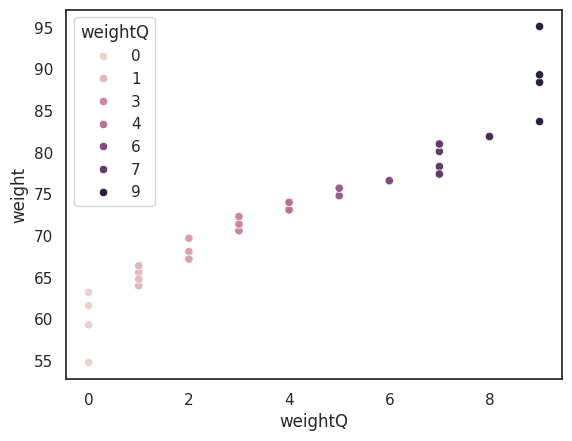

In [7]:
sns.scatterplot(data = data, x = "weightQ",  y = "weight", hue = "weightQ")